In [38]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'axes.titlesize': 10,
    'axes.labelsize': 18,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7
})

def smooth_signal(signal, window_size=3):
    return np.convolve(signal, np.ones(window_size)/window_size, mode='same')

# Load the pickle file
file_path = '/home/dg73/CogPhys/waveforms/wave_fusion/pred.pickle'
ta_file_path = '/home/dg73/CogPhys/waveforms/ta_cp+/pred.pickle'
tb_file_path = '/home/dg73/CogPhys/waveforms/tb_cp+/pred.pickle'
radar_file_path = '/home/dg73/CogPhys/waveforms/test_radar_all/pred.pickle'

with open(file_path, 'rb') as f:
    data = pickle.load(f)
    
with open(ta_file_path, 'rb') as f:
    ta_data = pickle.load(f)
    
with open(tb_file_path, 'rb') as f:
    tb_data = pickle.load(f)
    
with open(radar_file_path, 'rb') as f:
    radar_data = pickle.load(f)
    
#manually get index
idx = 0
for participant, chunk_ids in ta_data['participant_task_chunk_id_list']:
    if participant == 'v38_still' and chunk_ids == [0,1]:
        print(idx)
    idx+=1

# Extract the lists
ta_pred_list = ta_data['pred']
tb_pred_list = tb_data['pred']
radar_pred_list = radar_data['pred']
pred_list = data['pred']  # List of predicted waveforms
gt_list = data['gt']      # List of ground truth waveforms
participant_info = data['participant_task_chunk_id_list']  # List of participant info

# Sanity check
assert len(pred_list) == len(gt_list) == len(participant_info), "Mismatched lengths"

# Plot each waveform pair
for i in range(len(pred_list)):
#for i in range(100,130):
    #smooth the fusion waveforms
    # if "fusion" in file_path:
    #     pred = smooth_signal(pred_list[i][:150])
    #     print("smoothed")
    # else:
    pred = pred_list[i][:300]
    ta_pred = ta_pred_list[i][:300]
    tb_pred = tb_pred_list[i][:300]
    radar_pred = radar_pred_list[i][:300]
    gt = gt_list[i][:300]
    participant, chunk_ids = participant_info[i]
    
    if participant =='v38_still' and chunk_ids == [0,1]:
        print('index', i)
        #101

    '''
    plt.figure(figsize=(5, 4))
    plt.plot(pred, label='Fusion Predicted', linestyle='--', linewidth=1)
    plt.plot(ta_pred, label='TA Predicted', linestyle='--', linewidth=1)
    plt.plot(tb_pred, label='TB Predicted', linestyle='--', linewidth=1)
    plt.plot(radar_pred, label='Radar Predicted', linestyle='--', linewidth=1)
    plt.plot(gt, label='Ground Truth Resp', alpha=0.7, linewidth=1)
    plt.title(f"Participant: {participant}, Chunk IDs: {chunk_ids}")
    plt.xlabel("Time")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()  # You can change this to `plt.savefig(...)` if you want to save them instead
    '''


12
index 33


In [ ]:
# frame: /shared/ab227/CogPhys/chunked_dataset/____/rgb_left_0.npy

import numpy as np
import matplotlib.pyplot as plt

file_path = '/shared/ab227/CogPhys/chunked_dataset/v34_still/rgb_left_0.npy'  # replace with your actual file path

# Load the array
array = np.load(file_path)
frame_array = array[0]
print("Shape:", frame_array.shape)
plt.imshow(frame_array)
plt.show()

/tmp/ipykernel_2771430/3126710093.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


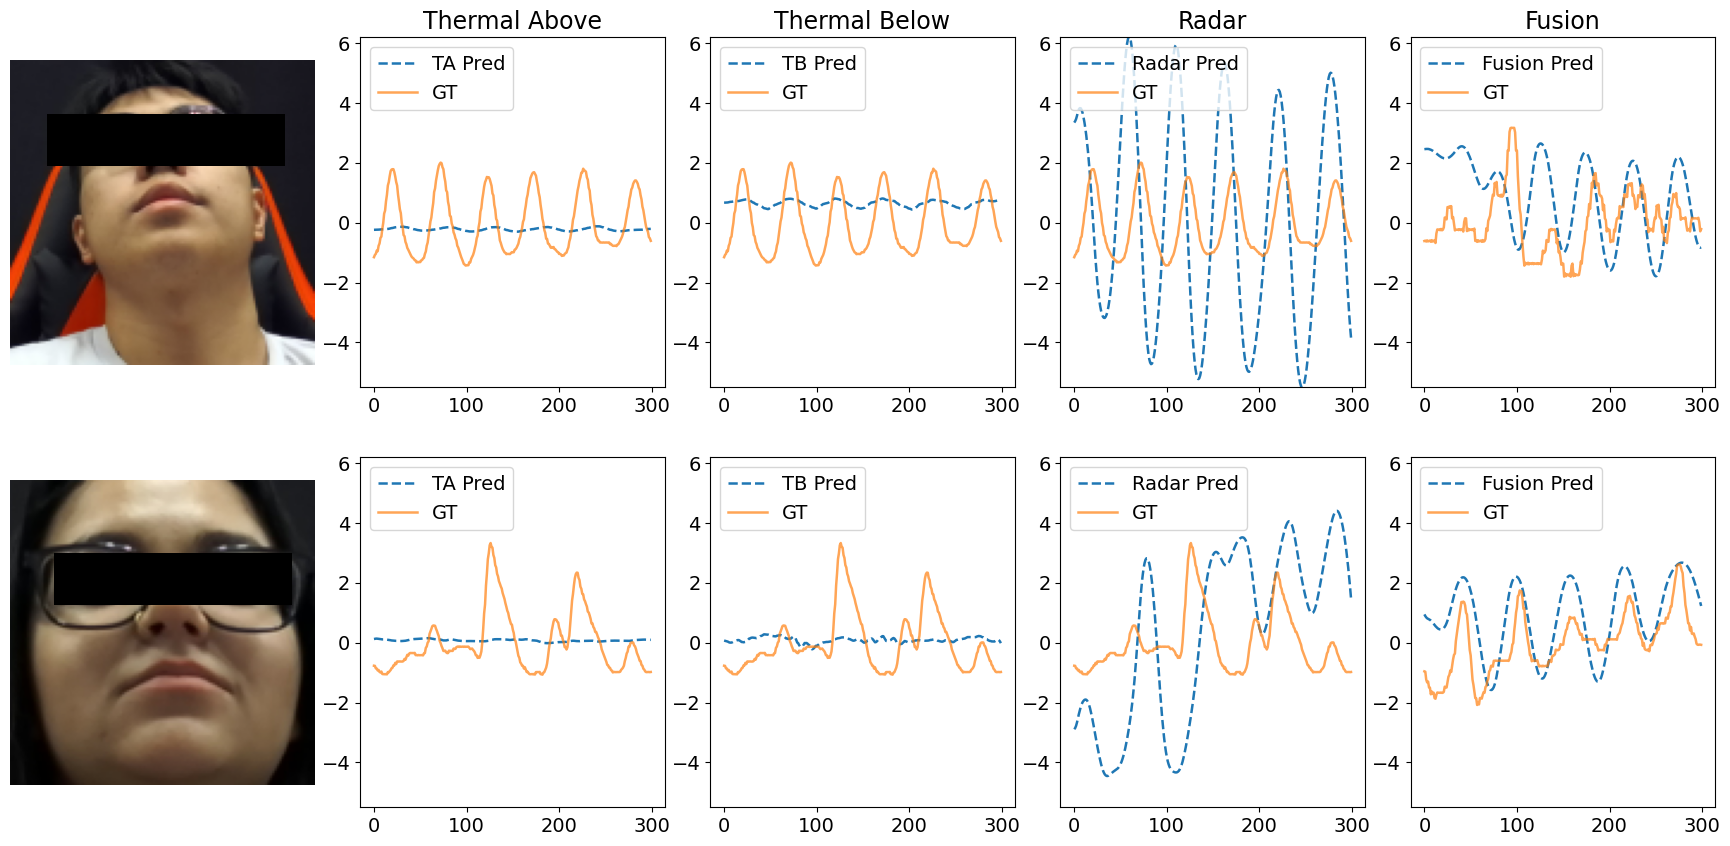

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
from matplotlib.patches import Rectangle

plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

'''
# --- Utility function to smooth a signal ---
def smooth_signal(signal, window_size=3):
    return np.convolve(signal, np.ones(window_size) / window_size, mode='same')
'''

# --- Load a pickle file ---
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# --- Load a frame from .npy file ---
def load_frame(participant, chunk_idx):
    frame_path = f'/shared/ab227/CogPhys/chunked_dataset/{participant}/rgb_left_0.npy'
    array = np.load(frame_path)
    return array[0]  # first frame of chunk

# --- Define paths to data ---
fusion_path = '/home/dg73/CogPhys/waveforms/wave_fusion/pred.pickle'
ta_file_path = '/home/dg73/CogPhys/waveforms/ta_cp+/pred.pickle'
tb_file_path = '/home/dg73/CogPhys/waveforms/tb_cp+/pred.pickle'
radar_file_path = '/home/dg73/CogPhys/waveforms/test_radar_all/pred.pickle'

# --- Load waveform data ---
fusion_data = load_pickle(fusion_path)
ta_data = load_pickle(ta_file_path)
tb_data = load_pickle(tb_file_path)
radar_data = load_pickle(radar_file_path)

# --- Define 3 specific subjects to visualize ---
target_subjects = [
    ('v11_pattern_rest', [4,5]),
    #('v34_number', [2,3]),
    #('v26_still', [2,3]),
    ('v38_still', [0, 1])
]

# --- Create GridSpec figure with adjusted column spacing ---
fig = plt.figure(figsize=(22, 10))
gs = gridspec.GridSpec(2, 5, width_ratios=[1, 1, 1, 1, 1], wspace=0.15, hspace=0.2)
axes = np.empty((2, 5), dtype=object)

# Assign axes from GridSpec
for row in range(2):
    for col in range(5):
        axes[row, col] = fig.add_subplot(gs[row, col])

for row, (participant, chunk_ids) in enumerate(target_subjects):
    key = (participant, chunk_ids)
    try:
        idx = fusion_data['participant_task_chunk_id_list'].index(key)
    except ValueError:
        print(f"Participant {key} not found.")
        continue

    # --- Frame ---
    frame = load_frame(participant, chunk_ids[0])
    axes[row, 0].imshow(frame)
    axes[row, 0].axis('off')
    
    if row==0:
        eye_bar = Rectangle(
        (15, 22),     # (x, y) coordinates — tweak as needed
        100,          # width of the bar (covers both eyes)
        22,           # height of the bar
        linewidth=0,
        edgecolor='none',
        facecolor='black'
        )
    elif row==1:
        eye_bar = Rectangle(
        (18, 30),     # (x, y) coordinates — tweak as needed
        100,          # width of the bar (covers both eyes)
        22,           # height of the bar
        linewidth=0,
        edgecolor='none',
        facecolor='black'
        )
    else:
        eye_bar = Rectangle(
        (12, 42),     # (x, y) coordinates — tweak as needed
        100,          # width of the bar (covers both eyes)
        22,           # height of the bar
        linewidth=0,
        edgecolor='none',
        facecolor='black'
        )
    
    # Add patch to the frame axis (leftmost column)
    axes[row, 0].add_patch(eye_bar)    
    

    # --- Thermal Above waveform ---
    ta_pred = ta_data['pred'][idx][:300]
    ta_gt = ta_data['gt'][idx][:300]
    axes[row, 1].plot(ta_pred, label='TA Pred', linewidth=1.8, linestyle='--')
    axes[row, 1].plot(ta_gt, label='GT', linewidth=1.8, alpha=0.7)
    if row == 0:
        axes[row, 1].set_title("Thermal Above")
    axes[row, 1].legend(loc='upper left')
    axes[row, 1].set_ylim(-5.5, 6.2)

    # --- Thermal Below waveform ---
    tb_pred = tb_data['pred'][idx][:300]
    tb_gt = tb_data['gt'][idx][:300]
    axes[row, 2].plot(tb_pred, label='TB Pred', linewidth=1.8, linestyle='--')
    axes[row, 2].plot(tb_gt, label='GT', linewidth=1.8, alpha=0.7)
    if row == 0:
        axes[row, 2].set_title("Thermal Below")
    axes[row, 2].legend(loc='upper left')
    axes[row, 2].set_ylim(-5.5, 6.2)

    # --- Radar waveform ---
    radar_pred = radar_data['pred'][idx][:300]
    radar_gt = radar_data['gt'][idx][:300]
    axes[row, 3].plot(radar_pred, label='Radar Pred', linewidth=1.8, linestyle='--')
    axes[row, 3].plot(radar_gt, label='GT', linewidth=1.8, alpha=0.7)
    if row == 0:
        axes[row, 3].set_title("Radar")
    axes[row, 3].legend(loc='upper left')
    axes[row, 3].set_ylim(-5.5, 6.2)

    # --- Fusion waveform ---
    fusion_pred = fusion_data['pred'][idx][:300]
    fusion_gt = fusion_data['gt'][idx][:300]
    axes[row, 4].plot(fusion_pred, label='Fusion Pred', linewidth=1.8, linestyle='--')
    axes[row, 4].plot(fusion_gt, label='GT', linewidth=1.8, alpha=0.7)
    if row == 0:
        axes[row, 4].set_title("Fusion")
    axes[row, 4].legend(loc='upper left')
    axes[row, 4].set_ylim(-5.5, 6.2)

plt.tight_layout()
plt.show()
